In [1]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset
from pathlib import Path
from torchvision import datasets
from torchinfo import summary
from sklearn.model_selection import train_test_split
import torch.nn as nn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,52,1,1,118,186,0,2,190,0,0.0,2,0,fixed,0
299,43,0,4,132,341,1,2,136,1,3.0,2,0,reversible,1
300,65,1,4,135,254,0,2,127,0,2.8,2,1,reversible,1
301,48,1,4,130,256,1,2,150,1,0.0,1,2,reversible,1


In [3]:
df.dtypes



age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal            str
target        int64
dtype: object

In [4]:
df.shape

(303, 14)

In [5]:
# check the distribution of the target variables
df.target.value_counts(normalize=True, dropna=False)

target
0    0.726073
1    0.273927
Name: proportion, dtype: float64

From this we can see that an acceptable baseline for the model is '0' as it is 72%, i.e is you predict 0 you are likely to be correct 72% of the times

Preprocessing
This dataset has both categorical variables and numeric variables.

It will be convenient (for later processing) to collect these groups of variables into two lists.

In [6]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg','exang', 'ca', 'thal']
numerical_variables = ['age', 'trestbps','chol', 'thalach', 'oldpeak', 'slope']

NNs require all their inputs to be numeric so we will first preprocess this raw data as follows:

one-hot encode the categorical variables
normalize the numeric variables
With the pandas get_dummies function, you can one-hot-encode in one line.

In [7]:
df = pd.get_dummies(df, columns=categorical_variables)

In [8]:
df.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope', 'target',
       'sex_0', 'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'fbs_0',
       'fbs_1', 'restecg_0', 'restecg_1', 'restecg_2', 'exang_0', 'exang_1',
       'ca_0', 'ca_1', 'ca_2', 'ca_3', 'thal_1', 'thal_2', 'thal_fixed',
       'thal_normal', 'thal_reversible'],
      dtype='str')

NNs work best when the inputs are all roughly in the same range. So standard practice is to standardize the numeric variables.

Before we do so, let's split the data into an 80% training set and 20% test set (why should we split before normalization?).

we do this because if we don't the test will be affected by a process used in the training i.e normalization, this is in a way kind of cheating our test data 

In [9]:
# zis is for datasets not dataframes
# g = torch.Generator()
# g.manual_seed(42)

# train_df, test_df = random_split(df, [0.8, 0.2], generator=g)

In [10]:
df_test = df.sample(frac=0.2, random_state=42)
df_train = df.drop(df_test.index)

In [11]:
df_train.shape

(242, 30)

Now to calculate the mean and std of the train to normalize it

In [12]:
mean = df_train[numerical_variables].mean()
std = df_train[numerical_variables].std()

mean, std

(age          54.268595
 trestbps    131.995868
 chol        246.512397
 thalach     149.805785
 oldpeak       1.032645
 slope         1.590909
 dtype: float64,
 age          9.059861
 trestbps    18.012789
 chol        48.485377
 thalach     23.132298
 oldpeak      1.169729
 slope        0.632783
 dtype: float64)

Let's standardize the train and test dataframes with these means and standard deviations.

In [13]:
df_train[numerical_variables] = (df_train[numerical_variables] - mean)/std
df_test[numerical_variables] = (df_test[numerical_variables] - mean)/std

In [14]:
df_train.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False



At this point, the data is entirely numeric.

The easiest way to feed data to Keras/Tensorflow is as Numpy arrays so we convert our two dataframes to Numpy arrays.

But i want to try using pytorch instead
 So i have to convert to tensor instead

In [15]:
non_numeric_cols = df_train.select_dtypes(include=['object']).columns
non_numeric_cols

Index([], dtype='str')

In [16]:
# Check the dtype of the numpy array
print(f"dtype before conversion: {df_train.drop('target', axis=1).values.dtype}")
print(f"First few rows:\n{df_train.drop('target', axis=1).values[:5]}")

dtype before conversion: object
First few rows:
[[0.9637460000632196 0.7219388572970076 -0.2786901431473242
  0.008395831553705848 1.0834606462798713 2.2268136645161465 False True
  False True False False False False True False False True True False
  True False False False False False True False False]
 [1.40525386947221 1.5546805325395048 0.814422938200559
  -1.8072474006137904 0.39954156861510737 0.6464942896982362 False True
  False False False False True True False False False True False True
  False False False True False False False True False]
 [1.40525386947221 -0.6659639347738212 -0.36118924362640975
  -0.8994257845300423 1.3399303004041578 0.6464942896982362 False True
  False False False False True True False False False True False True
  False False True False False False False False True]
 [-1.9060551510952177 -0.11080281794548966 0.07193103388878926
  1.6078910598917382 2.1093392627770173 2.2268136645161465 False True
  False False False True False True False True False 

In [17]:
df_train.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [18]:
# Find columns with boolean dtype
bool_cols = df_train.select_dtypes(include=['bool']).columns
print(f"Boolean columns: {list(bool_cols)}")

Boolean columns: ['sex_0', 'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'fbs_0', 'fbs_1', 'restecg_0', 'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'thal_1', 'thal_2', 'thal_fixed', 'thal_normal', 'thal_reversible']


In [19]:
# Convert boolean columns to 0/1 integers
df_train_numeric = df_train.copy()
df_test_numeric = df_test.copy()

for col in bool_cols:
    df_train_numeric[col] = df_train_numeric[col].astype(int)
    df_test_numeric[col] = df_test_numeric[col].astype(int)


df_train_numeric.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,0,1,0,...,1,0,0,0,1,0,0,0,1,0
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,0,1,0,...,1,0,0,1,0,0,0,0,0,1
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,0,1,0,...,0,1,0,0,0,0,0,0,1,0
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,1,0,0,...,0,1,0,0,0,0,0,0,1,0


In [20]:
# train = df_train.to_numpy()
# test = df_test.to_numpy()

# train_X = np.delete(train, 6, axis=1)
# train_y = np.delete(test, 6, axis=1)

# train_y = train[:,6]
# test_y = test[:, 6]

In [21]:
X = df_train_numeric.drop(columns=['target'])
y = df_train_numeric['target']

X.shape
x_train, x_val, y_train, y_val = train_test_split(X, y, train_size=0.8, random_state=42)

In [22]:
y_val.head()

30     0
8      1
188    0
260    0
297    0
Name: target, dtype: int64

In [23]:
train_X_tensor = torch.tensor(x_train.values, dtype=torch.float32)
train_y_tensor = torch.tensor(y_train.values, dtype=torch.float32)
val_X_tensor = torch.tensor(x_val.values, dtype=torch.float32)
val_y_tensor = torch.tensor(y_val.values, dtype=torch.float32)

In [24]:
test_X_tensor = torch.tensor(df_test_numeric.drop('target', axis=1).values, dtype=torch.float32)
test_y_tensor = torch.tensor(df_test_numeric.target.values, dtype=torch.float32)

In [25]:
train_dataset = TensorDataset(train_X_tensor, train_y_tensor)
val_dataset = TensorDataset(val_X_tensor, val_y_tensor)
test_dataset  = TensorDataset(test_X_tensor, test_y_tensor)

In [26]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Key Differences from Keras/TensorFlow:

## Aspect          Keras               Pytorch
### Data format	NumPy arrays or tf.data	Tensors + DataLoader
### Batching	Built into fit()	DataLoader
### Model definition	Sequential or functional API	nn.Module class
### Training loop	model.fit()	Manual loop
### Device	Automatic	Explicit (to(device))

Build a model

In [27]:
train_X_tensor.shape

torch.Size([193, 29])

In [28]:
num_columns = train_X_tensor.shape[1]
num_columns

29

Alternate way of building the model

In [29]:
# import torch
# import torch.nn as nn

# class SimpleNN(nn.Module):
#     def __init__(self, num_columns):
#         super(SimpleNN, self).__init__()
#         # Hidden layer: input -> 16 units with ReLU activation
#         self.hidden = nn.Linear(num_columns, 16)
#         self.relu = nn.ReLU()
        
#         # Output layer: 16 units -> 1 unit with Sigmoid activation
#         self.output = nn.Linear(16, 1)
#         self.sigmoid = nn.Sigmoid()
    
#     def forward(self, x):
#         # Feed input to hidden layer
#         x = self.hidden(x)
#         x = self.relu(x)
        
#         # Feed hidden layer output to output layer
#         x = self.output(x)
#         x = self.sigmoid(x)
        
#         return x

# # Create the model
# num_columns = X_train.shape[1]  # or whatever your number of features is
# model = SimpleNN(num_columns)

# print(model)

Using nn.Sequential

In [30]:
model = nn.Sequential(
    nn.Linear(in_features=num_columns, out_features=16),
    nn.ReLU(),
    nn.Linear(in_features=16, out_features=1),
    nn.Sigmoid()
)

In [31]:
summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─Linear: 1-1                            480
├─ReLU: 1-2                              --
├─Linear: 1-3                            17
├─Sigmoid: 1-4                           --
Total params: 497
Trainable params: 497
Non-trainable params: 0

In [32]:
# Let's hand-calculate the number of parameters to verify.
(29 + 1)* 16 + (16 + 1) * 1

497

In [33]:
# Define the loss_fun and optimizer
loss_fun = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.001)

Training the Model

In [34]:
epoch = 300

In [38]:
train_losses= []
val_losses = []
train_accs =[]
val_accs = []

def accuracy(outputs, labels):
    preds = (outputs > 0.5).float()
    return (preds == labels).float().mean()

for epoch in range(300):
    # -------- TRAIN --------
    model.train()
    total_loss, total_acc = 0, 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        y_batch = y_batch.unsqueeze(1)

        outputs = model(X_batch)
        loss = loss_fun(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy(outputs, y_batch).item()

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(total_acc / len(train_loader))

    # -------- VALIDATION --------
    model.eval()
    val_loss, val_acc = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_batch = y_batch.unsqueeze(1)
            outputs = model(X_batch)
            loss = loss_fun(outputs, y_batch)

            val_loss += loss.item()
            val_acc += accuracy(outputs, y_batch).item()

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(val_acc / len(val_loader))

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}, "
          f"Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

Epoch 1: Train Loss=0.1252, Val Loss=0.4821, Train Acc=0.9375, Val Acc=0.7868
Epoch 2: Train Loss=0.1267, Val Loss=0.4840, Train Acc=0.9375, Val Acc=0.7868
Epoch 3: Train Loss=0.1195, Val Loss=0.4846, Train Acc=0.9375, Val Acc=0.7574
Epoch 4: Train Loss=0.1188, Val Loss=0.4847, Train Acc=0.9375, Val Acc=0.7574
Epoch 5: Train Loss=0.1210, Val Loss=0.4853, Train Acc=0.9420, Val Acc=0.7574
Epoch 6: Train Loss=0.1231, Val Loss=0.4864, Train Acc=0.9420, Val Acc=0.7574
Epoch 7: Train Loss=0.1176, Val Loss=0.4869, Train Acc=0.9420, Val Acc=0.7574
Epoch 8: Train Loss=0.1172, Val Loss=0.4871, Train Acc=0.9420, Val Acc=0.7574
Epoch 9: Train Loss=0.1212, Val Loss=0.4879, Train Acc=0.9509, Val Acc=0.7574
Epoch 10: Train Loss=0.1187, Val Loss=0.4887, Train Acc=0.9509, Val Acc=0.7574
Epoch 11: Train Loss=0.1165, Val Loss=0.4880, Train Acc=0.9464, Val Acc=0.7574
Epoch 12: Train Loss=0.1159, Val Loss=0.4872, Train Acc=0.9464, Val Acc=0.7574
Epoch 13: Train Loss=0.1154, Val Loss=0.4874, Train Acc=0.942

Model Evaluation

In [36]:
model.eval()
test_loss, test_acc = 0, 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_batch = y_batch.unsqueeze(1)
        outputs = model(X_batch)
        loss = loss_fun(outputs, y_batch)

        test_loss += loss.item()
        test_acc += accuracy(outputs, y_batch).item()

test_loss /= len(test_loader)
test_acc /= len(test_loader)

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3913, Test Accuracy: 0.8529


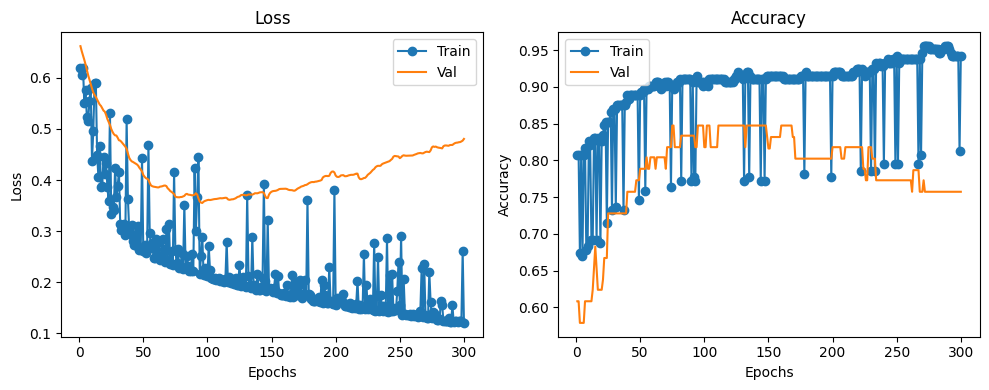

In [37]:
epochs = range(1, len(train_losses) + 1)
plt.figure(figsize=(10, 4))

# ---- Loss ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'o-', label='Train')
plt.plot(epochs, val_losses, '-', label='Val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# ---- Accuracy ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, 'o-', label='Train')
plt.plot(epochs, val_accs, '-', label='Val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()